# Audit Atribusi Temporal Bidirectional Mamba-2 — Notebook Induk

Notebook tunggal yang menyatukan seluruh penelitian: dari verifikasi data sampai temuan akhir,
beserta seluruh gambar dan validasi silang terhadap naskah.

Dibangun **2026-09-04** oleh `scripts/build_nb_master.py`.

---

# Ringkasan Hasil

## Yang diuji

Apakah arsitektur sekuens modern dengan attention pooling dapat **melokalisasi** gangguan motorik
Parkinson pada sumbu waktu — bukan sekadar mengklasifikasi rekaman — dan apakah peta temporal yang
dihasilkannya layak diperlakukan sebagai penjelasan.

Tiga encoder yang dapat dipertukarkan dengan bottleneck identik: **BiGRU** (baseline),
**BiMamba-2** (arm pra-registrasi), dan **BiMamba-3** (arm eksploratori). Dua basis data:
**UCI 395** (77 subjek) dan **NewHandPD** (66 subjek).

## Vonis per Rumusan Masalah

| RM | Pertanyaan | Vonis |
|---|---|---|
| 1 | Arsitektur yang memberi prediksi sekaligus peta per segmen waktu | **Tercapai** |
| 2 | Perbandingan BiGRU, BiMamba-2, BiMamba-3 | **Tidak terbedakan pada akurasi**; ketiganya kalah oleh baseline fitur agregat |
| 3 | Replikasi metode pada basis data lintas | **Berhasil** — membantah ramalan peneliti sendiri |
| 4 | Kesetiaan bobot atensi terhadap atribusi Shapley | **Terjawab**: rendah, sesuai yang diperkirakan teori |
| 5 | Keselarasan atribusi terhadap penanda motorik independen | **Ditolak pada rancangan yang berdaya** (35 kontrol, MDE 0,0450) |

## Temuan utama

**Peta temporal runtuh jauh sebelum akurasi bergerak.** Empat pengukuran yang tidak saling
bergantung memberi arah yang sama, dengan selisih besaran **tujuh sampai empat puluh tiga kali
lipat** — dihitung ulang oleh Seksi 7 notebook ini, bukan disalin.
Penelitian yang menilai model hanya dari akurasi tidak akan melihat kerusakan itu sama sekali.

**Peringkat arsitektur adalah sifat kohort, bukan sifat arsitektur.** Enam pembalikan tercatat,
tiga di antaranya signifikan di kedua arah.

**Satu-satunya sumbu yang tidak dapat membalik adalah retensi lintas kohort**, dan alasannya
struktural: ia mengukur perpindahan antar kohort itu sendiri. Pada sumbu itu keluarga Mamba
mempertahankan AUC sementara BiGRU dan ketiga baseline fitur kehilangan.

## Bukti bahwa hasil ini tidak sirkular

- **Penanda dihitung dari kanal yang sengaja ditahan dari model.** Pada UCI 395 dari koordinat pena;
  pada NewHandPD dari kanal 4–6 BiSP yang tidak pernah dilihat model.
- **Kontrol label acak** meruntuhkan performa dari 0,9419 menjadi median 0,341 — kebocoran pipeline
  akan menaikkan, bukan menurunkan.
- **Kontrol positif dengan sinyal sintetis berlokasi diketahui** menetapkan batas atas terukur
  pipeline sebesar 0,1438, sehingga angka kesetiaan terbaca pada konteksnya.
- **Tujuh klaim ditarik** selama penelitian, tiga di antaranya signifikan lalu membalik signifikan.
- **Dua ramalan pra-registrasi peneliti sendiri terbukti keliru** dan dibiarkan terbaca.

## Keterbatasan yang harus dibawa ke naskah

1. **Tujuh subjek kontrol** pada tugas analisis primer. MDE 0,1450 — dua kali ambangnya sendiri.
2. **Sebab kegagalan analisis primer tidak teridentifikasi**: dua besaran sepele memisahkan kelompok
   hampir sebaik model, dan pada n ini tidak satu pun dapat dibedakan dari yang lain.
3. **Sekitar 75 persen** selisih keselarasan pada STCP merupakan artefak dukungan penanda.
4. **Nilai p per-arm tidak stabil terhadap jumlah seed** — satu arm melintasi taraf nyata dua kali
   dalam dua arah berbeda antara satu, tiga, dan lima seed.
5. **Ambang pada dua analisis dipinjam**, bukan dikalibrasi ulang untuk penanda dan perangkatnya.

## Cara membaca notebook ini

Notebook ini **tidak melatih apa pun**. Ia memuat artefak yang sudah dihitung di `results/`,
menghitung ulang seluruh angka kunci dari sana, menyimpan tiap gambar ke `figures/`, dan diakhiri
Seksi 8 yang membandingkan angka hasil hitungannya sendiri terhadap yang tertulis di naskah. Bila
ada yang tidak cocok, seksi itu akan berteriak.

Berjalan dari atas ke bawah dalam hitungan menit, tanpa GPU.

---

# **SEKSI 1 — Lingkungan dan Pemuatan Artefak**

Seluruh angka pada notebook ini berasal dari `results/`. Sel di bawah memuat semuanya sekaligus dan
melaporkan apa yang ada dan apa yang hilang, sehingga kegagalan pemuatan tidak menyamar sebagai
angka yang salah.

In [1]:
import sys, json, pickle, warnings
from pathlib import Path
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
warnings.filterwarnings("ignore")

AKAR = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
HASIL, GAMBAR = AKAR / "results", AKAR / "figures"
GAMBAR.mkdir(exist_ok=True)
sys.path.insert(0, str(AKAR / "src"))
from viz import pasang_gaya, WARNA, TINTA, rapikan
pasang_gaya()

def simpan(fig, nama):
    """Simpan tiap gambar ke figures/ dalam PNG resolusi tinggi dan PDF vektor."""
    for ext, kw in [("png", dict(dpi=200)), ("pdf", {})]:
        fig.savefig(GAMBAR / f"{nama}.{ext}", bbox_inches="tight", **kw)
    print(f"  tersimpan: figures/{nama}.png dan .pdf")

T = {}
for f in sorted(HASIL.glob("*.csv")):
    T[f.stem] = pd.read_csv(f)
print(f"{len(T)} tabel CSV dimuat dari results/")
print(f"{len(list(HASIL.glob('*.pkl')))} artefak pickle tersedia")

67 tabel CSV dimuat dari results/
13 artefak pickle tersedia


In [2]:
# Angka kunci ditarik satu kali di sini, lalu dipakai ulang di seluruh notebook.
# Menariknya di satu tempat mencegah angka yang sama berbeda antar seksi.
A = {}
A["s3"]      = T["s3_per_seed"]
A["s5"]      = T["s5_per_seed"]
A["s5_kls"]  = T["s5_klasifikasi"]
A["s5_sel"]  = T["s5_keselarasan"]
A["s6"]      = T["s6_kesetiaan"]
A["s7_prim"] = T["s7_analisis_primer"]
A["s7_boot"] = T["s7_bootstrap_peta"]
A["s7_pas"]  = T["s7_berpasangan_alpha_phi"]
A["s7_seed"] = T["s7_kestabilan_seed"]
A["a0"]      = T["a0_ringkas"]
A["a3_mde"]  = T["a3_mde"]
A["b1"]      = T["b1_retensi_lima_seed"]
A["b1_seed"] = T["b1_kehilangan_per_seed"]
A["base"]    = T["a_baseline_fitur"]
A["base_lk"] = T["a_baseline_lintas_kohort"]
A["rm5"]     = T["rm5_selisih_kelompok_newhandpd"]
A["rm5_mde"] = T["rm5_mde"]
A["d4"]      = T["d4_durasi_postur_lintas_tugas"]

# Palet dan label dipakai seluruh notebook; ditetapkan sekali di sini.
warna = {"gru": WARNA["netral"], "mamba2": WARNA["biru"], "mamba3": WARNA["jingga"]}
nama = {"gru": "BiGRU", "mamba2": "BiMamba-2", "mamba3": "BiMamba-3"}
nama_p = {**nama, "regresi_logistik": "Regresi logistik", "svm_rbf": "SVM RBF",
          "random_forest": "Random forest"}

for k, v in A.items():
    print(f"  {k:9s} {v.shape[0]:3d} baris x {v.shape[1]:2d} kolom")

  s3         30 baris x  6 kolom
  s5         30 baris x  3 kolom
  s5_kls      3 baris x  5 kolom
  s5_sel      3 baris x  7 kolom
  s6          3 baris x  6 kolom
  s7_prim     1 baris x 16 kolom
  s7_boot     6 baris x  9 kolom
  s7_pas      3 baris x  9 kolom
  s7_seed     3 baris x  8 kolom
  a0          1 baris x 12 kolom
  a3_mde      1 baris x  7 kolom
  b1          3 baris x 12 kolom
  b1_seed    15 baris x  5 kolom
  base        6 baris x  6 kolom
  base_lk     6 baris x  6 kolom
  rm5         6 baris x 11 kolom
  rm5_mde     1 baris x  7 kolom
  d4          7 baris x 10 kolom


---

# **SEKSI 0 — Latar Belakang, Posisi, dan Kontribusi**

## Latar belakang

Diagnosis Parkinson bertumpu pada penilaian motorik yang, dalam praktik, dilakukan secara
**semikuantitatif oleh klinisi**. Keterbatasannya subjektivitas dan ketiadaan resolusi temporal.
Tablet digitizer memungkinkan perekaman **proses** menggambar — koordinat, tekanan, sudut, dan
waktu, pada puluhan sampai ratusan sampel per detik — sehingga objek analisisnya menjadi deret waktu
multivariat, bukan citra.

## Apa yang sudah dikerjakan peneliti terdahulu

| Pendekatan | Contoh | Perumusan tugas |
|---|---|---|
| Fitur kinematik dan tekanan agregat | Drotár dkk. | Satu vektor per rekaman |
| Visi komputer berbasis citra | Pereira dkk. | Sumbu waktu **dibuang** |
| Konvolusi 1D + Bidirectional GRU | Diaz dkk. | Satu label per rekaman |

## Kesenjangan yang tersisa

Hampir seluruhnya merumuskan tugas sebagai **klasifikasi tingkat sampel**: satu rekaman menjadi satu
keputusan biner. Perumusan itu membuang informasi yang secara klinis bernilai — **kapan** gangguan
motorik muncul di sepanjang rekaman. Padahal informasi itulah yang lebih mendekati cara klinisi
menilai.

## Kontribusi penelitian ini

1. **Merumuskan ulang tugas** dari klasifikasi menjadi **lokalisasi temporal**, dengan peta bobot
   per segmen waktu sebagai keluaran utama.
2. **Menguji kesahihan peta itu terhadap dua acuan yang berbeda sifat**: atribusi Shapley (aksioma
   kontribusi terhadap keluaran) dan penanda motorik yang dihitung dari kanal yang **sengaja ditahan
   dari model**.
3. **Memasuki perdebatan atensi-sebagai-penjelasan dari sisi yang belum dipakai.** Perdebatan Jain &
   Wallace lawan Wiegreffe & Pinter berlangsung pada domain tanpa kebenaran acuan eksternal. Domain
   tulisan tangan medis memiliki keduanya.
4. **Mengukur seberapa rapuh peta temporal itu sendiri** terhadap pergantian arsitektur, kohort,
   seed, dan resolusi — yang ternyata menjadi temuan utamanya.

## Pergeseran dari usulan awal, dan alasannya

| Yang berubah | Dari | Menjadi | Sebab |
|---|---|---|---|
| Peran NewHandPD | target transfer | **replikasi independen** | Tidak memuat koordinat pena, sehingga lima dari enam kanal model tidak dapat dibentuk |
| Protokol validasi | LOSO | **StratifiedGroupKFold k=5** | ~1600 run tidak muat anggaran delapan jam; tradeoff terukur mendekati nol |
| Jumlah arm | dua | **tiga** | BiMamba-3 terbit di tengah penelitian; ditambahkan sebagai arm eksploratori yang dikunci dari aturan keputusan |

## Prinsip yang dipegang, dan konsekuensinya

**Tanpa fallback.** Analisis pra-registrasi yang menyediakan rute alternatif bagi dirinya sendiri
bukan lagi klaim yang dapat gagal, melainkan pohon keputusan yang menyamar sebagai komitmen tunggal.
Konsekuensinya langsung: **analisis primer gagal, dan kegagalan itu tidak dapat dihindari.**

---

# **SEKSI 1b — Data, Prapemrosesan, dan Pemisahan Kanal**

## Dua basis data

| | UCI 395 | NewHandPD |
|---|---|---|
| Subjek | 77 (62 PD / 15 HC) | 66 (31 PD / 35 HC) |
| Perangkat | tablet digitizer | smart pen BiSP |
| Negara | Turki | Brasil |
| Tugas dipakai | SST, DST, STCP | 4 spiral |
| Frekuensi asli | 127,52 Hz | 1000 Hz |
| **Komposisi kelas** | timpang ke PD | **terbalik arah** |

Komposisi kelas yang terbalik arah bukan kebetulan yang mengganggu — ia justru menguatkan replikasi,
sebab model yang sekadar menghafal prior kelas tidak akan berpindah.

## Pemisahan kanal, yang membuat penanda benar-benar independen

Kekuatan rancangan ini terletak pada satu hal: **penanda dihitung dari kanal yang sengaja tidak
diberikan kepada model.** Tanpa itu, keselarasan yang terukur dapat dijelaskan sebagai model membaca
ulang masukannya sendiri.

| Basis data | Diberikan ke model | **Ditahan**, hanya untuk penanda |
|---|---|---|
| UCI 395 | dx, dy, kecepatan, percepatan, jerk, tekanan | **koordinat absolut** |
| NewHandPD | turunan pertama & kedua kanal 1–3 | **kanal 4–6: tilt & akselerasi X, Y, Z** |

## Prapemrosesan

Penyeragaman frekuensi sampling bersifat **wajib**, dan ternyata diperlukan bahkan di dalam satu
basis data. Selisih timestamp UCI 395 bersifat **bimodal** — 57,6 persen bernilai 7 ms dan 39,9
persen bernilai 9 ms — sehingga median menyesatkan dan turunan tidak boleh dihitung langsung dari
data mentah. Rata-rata selisih 7,842 ms memberi frekuensi sebenarnya 127,52 Hz, bukan 142,86 Hz
sebagaimana dilaporkan verifikasi awal.

  tersimpan: figures/data_kanal_dan_tugas.png dan .pdf


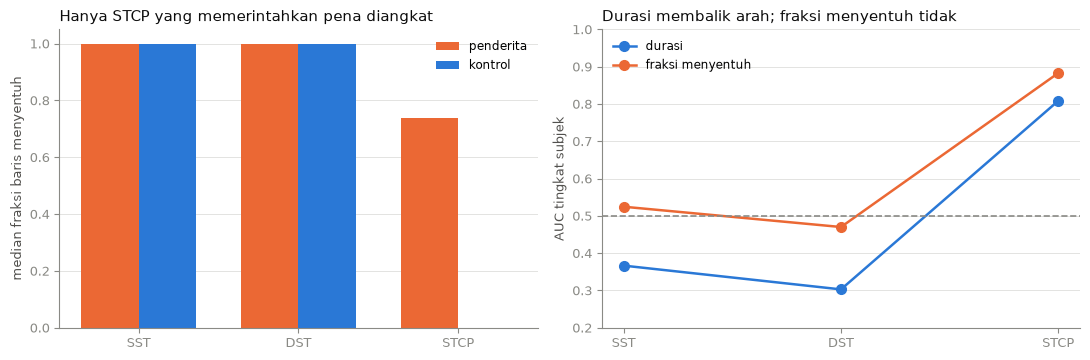

In [3]:
import pickle
d4 = A["d4"]
fig, ax = plt.subplots(1, 2, figsize=(11, 3.7))

sen = d4[d4.besaran == "fraksi_sentuh"]
xx = np.arange(len(sen)); w = 0.36
ax[0].bar(xx - w/2, sen.pd_median, w, color=WARNA["jingga"], label="penderita")
ax[0].bar(xx + w/2, sen.hc_median, w, color=WARNA["biru"], label="kontrol")
ax[0].set_xticks(xx); ax[0].set_xticklabels(sen.tugas)
ax[0].set_ylabel("median fraksi baris menyentuh")
ax[0].set_title("Hanya STCP yang memerintahkan pena diangkat", loc="left", fontsize=10.5)
ax[0].legend(frameon=False, fontsize=8.5)

for j, (b, lab) in enumerate([("durasi", "durasi"), ("fraksi_sentuh", "fraksi menyentuh")]):
    v = d4[d4.besaran == b]
    ax[1].plot(range(len(v)), v.auc, "o-", lw=1.8, ms=7,
               color=[WARNA["biru"], WARNA["jingga"]][j], label=lab)
ax[1].axhline(0.5, color=TINTA["redup"], ls="--", lw=1.2)
ax[1].set_xticks(range(3)); ax[1].set_xticklabels(["SST", "DST", "STCP"])
ax[1].set_ylabel("AUC tingkat subjek"); ax[1].set_ylim(0.2, 1.0)
ax[1].set_title("Durasi membalik arah; fraksi menyentuh tidak", loc="left", fontsize=10.5)
ax[1].legend(frameon=False, fontsize=8.5)
for a in ax: rapikan(a)
plt.tight_layout(); simpan(fig, "data_kanal_dan_tugas"); plt.show()

---

# **SEKSI 2b — Rumusan Masalah 4: Kesetiaan Atensi terhadap Atribusi Shapley**

## Mengapa pertanyaan ini perlu dijawab lebih dulu

Tanpa atribusi Shapley, ketidakselarasan atensi terhadap penanda memiliki **dua penjelasan
berlawanan yang tidak dapat dibedakan**: model tidak menggunakan sinyal motorik, atau model
menggunakannya namun peta atensi gagal merepresentasikannya. Phi dihadirkan justru untuk menguraikan
ambiguitas itu.

## Yang sudah diketahui teori, dan yang belum

Ethayarajh dan Jurafsky membuktikan secara formal bahwa, kecuali pada kasus degenerat, bobot atensi
**tidak dapat** merupakan nilai Shapley. Kesetiaan yang rendah karena itu **bukan temuan mengejutkan**
— ia yang diperkirakan teori. Yang disumbangkan pengukuran ini adalah **besarannya**, dan konteks
yang membuatnya terbaca: batas atas terukur pipeline pada kondisi ideal.

## Batas atas terukur, dan mengapa ia menohok

Pada kontrol positif dengan sinyal sintetis berlokasi diketahui dan deteksi sempurna, kesetiaan
alpha terhadap phi hanya mencapai **0,1438**. Itu **batas struktural**, bukan kegagalan arsitektur
tertentu. Angka kesetiaan apa pun harus dibaca terhadap batas itu, bukan terhadap 1,0.

  tersimpan: figures/kesetiaan_atensi.png dan .pdf


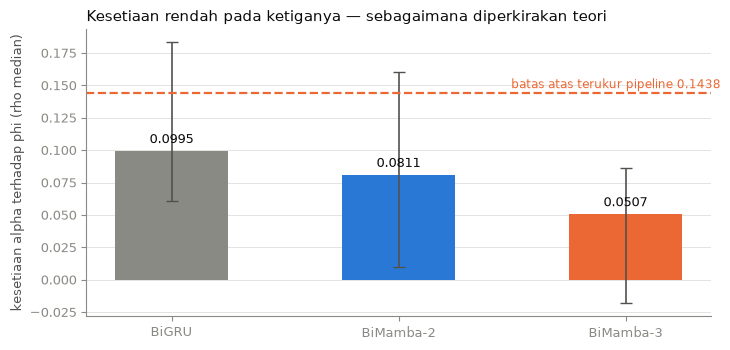

  BiGRU        0.0995  = 69 persen dari batas atas
  BiMamba-2    0.0811  = 56 persen dari batas atas
  BiMamba-3    0.0507  = 35 persen dari batas atas


In [4]:
s6 = A["s6"]; atap = float(T["s6_batas_atas_kesetiaan"].nilai.iloc[0])
fig, ax = plt.subplots(figsize=(7.4, 3.6))
u = s6.set_index("arsitektur").reindex(["gru", "mamba2", "mamba3"])
xx = np.arange(3)
ax.bar(xx, u.rho_median, 0.5, color=[warna[a] for a in u.index])
ax.errorbar(xx, u.rho_median, yerr=[u.rho_median - u.rho_q25, u.rho_q75 - u.rho_median],
            fmt="none", ecolor=TINTA["sekunder"], elinewidth=1.2, capsize=4)
ax.axhline(atap, color=WARNA["jingga"], ls="--", lw=1.6)
ax.text(2.42, atap + 0.004, f"batas atas terukur pipeline {atap:.4f}",
        fontsize=8.5, color=WARNA["jingga"], ha="right")
for i, v in enumerate(u.rho_median):
    ax.text(i, v + 0.006, f"{v:.4f}", ha="center", fontsize=9, color=TINTA["utama"])
ax.set_xticks(xx); ax.set_xticklabels([nama[a] for a in u.index])
ax.set_ylabel("kesetiaan alpha terhadap phi (rho median)")
ax.set_title("Kesetiaan rendah pada ketiganya — sebagaimana diperkirakan teori",
             loc="left", fontsize=10.5)
rapikan(ax); plt.tight_layout(); simpan(fig, "kesetiaan_atensi"); plt.show()

for a_ in ["gru", "mamba2", "mamba3"]:
    v = float(u.loc[a_, "rho_median"])
    print(f"  {nama[a_]:12s} {v:.4f}  = {v/atap*100:.0f} persen dari batas atas")

---

# **SEKSI 2c — Generalisasi Lintas Tugas (S4): Transfer Putus, dan Terbalik**

Leave-one-task-out menguji langsung sifat yang diklaim — apakah tanda motorik bertahan lintas tugas
— bukan proksinya. Hasilnya menjadi dasar ramalan pra-registrasi untuk Skenario S5, dan ramalan itu
kemudian terbukti keliru.

kolom: ['arsitektur', 'latih', 'uji', 'auc', 'n_subjek', 'n_hc']


  tersimpan: figures/s4_matriks_lintas_tugas.png dan .pdf


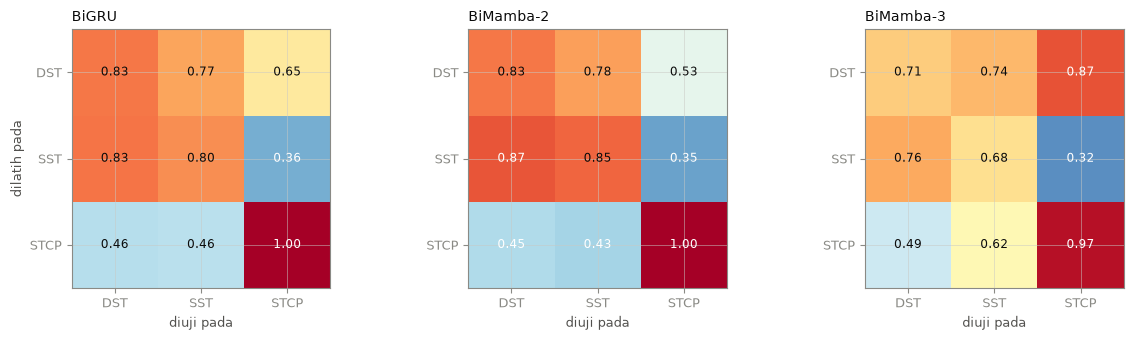

In [5]:
mt = T["s4_matriks_tugas"]
print("kolom:", list(mt.columns))
piv = {}
for a_ in ["gru", "mamba2", "mamba3"]:
    s = mt[mt.arsitektur == a_] if "arsitektur" in mt.columns else mt
    if len(s) == 0: continue
    kol = [c for c in ["auc", "nilai", "skor"] if c in s.columns]
    if not kol: continue
    piv[a_] = s.pivot(index="latih", columns="uji", values=kol[0]) if {"latih","uji"} <= set(s.columns) else None

ada = {k: v for k, v in piv.items() if v is not None}
if ada:
    fig, ax = plt.subplots(1, len(ada), figsize=(4.1*len(ada), 3.5))
    ax = np.atleast_1d(ax)
    for i, (a_, m) in enumerate(ada.items()):
        im = ax[i].imshow(m.values, cmap="RdYlBu_r", vmin=0.2, vmax=1.0)
        ax[i].set_xticks(range(len(m.columns))); ax[i].set_xticklabels(m.columns)
        ax[i].set_yticks(range(len(m.index))); ax[i].set_yticklabels(m.index)
        for r in range(m.shape[0]):
            for c in range(m.shape[1]):
                v = m.values[r, c]
                ax[i].text(c, r, f"{v:.2f}", ha="center", va="center", fontsize=8.5,
                           color="white" if (v < 0.45 or v > 0.85) else TINTA["utama"])
        ax[i].set_title(nama[a_], loc="left", fontsize=10)
        ax[i].set_xlabel("diuji pada"); 
        if i == 0: ax[i].set_ylabel("dilatih pada")
    plt.tight_layout(); simpan(fig, "s4_matriks_lintas_tugas"); plt.show()
else:
    display(mt.head(12))
    print("Struktur matriks tidak sesuai dugaan; tabel ditampilkan apa adanya.")

**Enam dari enam sel yang melibatkan STCP berada di bawah 0,5** pada kedua arm pra-registrasi — itu
**anti-prediktif**, bukan sekadar gagal. SST dan DST sebaliknya saling mentransfer hampir setara
acuan dalam-tugasnya.

Dugaan bahwa arah diskriminatif fiturnya membalik **diuji dan gugur**: seluruh korelasi
point-biserial bertanda sama. Mekanismenya sampai sekarang **belum diketahui**, dan dinyatakan
demikian alih-alih dikarang.

**Kekeliruan penalaran yang kemudian terungkap.** Dari S4 disimpulkan model mempelajari aturan khas
tugas, sehingga lintas basis data pasti gagal pula. Langkah kedua itu salah: kegagalan S4 terpusat
pada **STCP**, tugas menahan pena, sedangkan replikasi memakai tugas spiral yang sekerabat SST/DST.

---

# **SEKSI 2d — Uji Kewarasan: Bukti bahwa Pipeline Tidak Bocor**

Klaim apa pun tidak bermakna bila pipeline-nya bocor. Dua kontrol dijalankan.

In [6]:
la = T["s8_label_acak"]; ab = T["s8_permutasi_ablasi"]
print("Kontrol label acak — kebocoran akan MENAIKKAN performa, bukan menurunkan")
display(la.round(4))
print(); print("Ablasi mean pooling — apakah attention pooling memberi keuntungan prediktif?")
display(ab.round(4))

Kontrol label acak — kebocoran akan MENAIKKAN performa, bukan menurunkan


,pengacakan,auc
0,0,0.2677
1,1,0.3409
2,2,0.3645



Ablasi mean pooling — apakah attention pooling memberi keuntungan prediktif?


,arsitektur,auc_asli,auc_bobot_diacak,auc_mean_pooling,geser_logit_median,korelasi_logit
0,mamba2,0.9355,0.8656,0.9258,4.8055,0.7104
1,gru,0.9548,0.9398,0.9667,3.2033,0.8340
2,mamba3,0.9409,0.9258,0.9237,2.2197,0.8555


**Kontrol label acak** meruntuhkan performa dari 0,9419 menjadi median 0,341. Kebocoran akan
menaikkan, bukan menurunkan, sehingga tidak ada tanda kebocoran. Nilai di bawah 0,5 sudah ditelusuri
dan sebagian besar terjelaskan sebagai undian permutasi yang rendah; sebaran nolnya baru bersandar
pada tiga pengacakan sehingga **belum layak disebut terkarakterisasi**, dan itu dinyatakan.

**Ablasi mean pooling** memberi hasil yang lebih berdampak: attention pooling **tidak memberi
keuntungan prediktif sama sekali**. Konsekuensinya, pembenaran arsitektural atas dasar performa
gugur, dan bahasa klaim menyempit menjadi: *attention pooling menyediakan peta temporal tanpa biaya
akurasi* — bukan *meningkatkan akurasi sekaligus memberi peta*.

---

# **SEKSI 2 — Rumusan Masalah 2: Perbandingan Arsitektur**

## Aturan keputusan, ditetapkan sebelum data dilihat

Klaim keunggulan antar arsitektur **tidak** dibuat kecuali selisihnya melampaui variansi antar fold
dan antar seed. Aturan itu dibekukan pada Subbab 3.7 naskah dan dihitung **hanya** dari dua arm
pra-registrasi, sehingga penambahan BiMamba-3 tidak dapat menggeser vonisnya.

Bentuk aturannya memiliki kelemahan yang dinyatakan terbuka: ia membandingkan selisih terhadap
simpangan baku fold **tunggal** (0,0613), padahal yang dibandingkan estimasi tergabung lima fold
yang galat bakunya 0,0613/√5 = 0,0274. Dengan pembanding yang lebih tepat itu selisih 0,0244 masih
tidak terlampaui, namun jaraknya menjadi sangat tipis. **Aturan tidak diubah**, dan kelemahannya
dicatat agar pembaca menilai sendiri.

In [7]:
s3 = A["s3"]
ring = (s3.groupby("arsitektur").auc.agg(["mean", "std", "count"])
          .rename(columns={"mean": "AUC rerata", "std": "sb antar seed", "count": "n seed"}))
ring = ring.reindex(["gru", "mamba2", "mamba3"])
display(ring.round(4))

m2 = s3[(s3.arsitektur == "mamba2") & (s3.seed < 3)].auc.mean()
gr = s3[(s3.arsitektur == "gru") & (s3.seed < 3)].auc.mean()
print(f"\nSelisih BiMamba-2 dikurangi BiGRU, tiga seed pra-registrasi : {m2-gr:+.4f}")
print(f"Ambang tak-terbedakan (sb antar fold)                       :  0,0613")
print(f"-> {'UNGGUL' if abs(m2-gr) > 0.0613 else 'TIDAK TERBEDAKAN, tidak ada klaim dibuat'}")

,AUC rerata,sb antar seed,n seed
arsitektur,,,
gru,0.9503,0.0156,10
mamba2,0.9338,0.0172,10
mamba3,0.9213,0.0240,10



Selisih BiMamba-2 dikurangi BiGRU, tiga seed pra-registrasi : -0.0244
Ambang tak-terbedakan (sb antar fold)                       :  0,0613
-> TIDAK TERBEDAKAN, tidak ada klaim dibuat


## Kestabilan antar seed: satu klaim yang ditarik

Pada tiga seed, simpangan baku AUC tampak naik berurutan searah ekspresivitas state, dan sempat
dibaca sebagai temuan. **Klaim itu ditarik.** Dua seed tambahan sudah cukup membalikkan urutannya.
Gambar di bawah memperlihatkan mengapa.

  tersimpan: figures/s3_kestabilan_seed.png dan .pdf


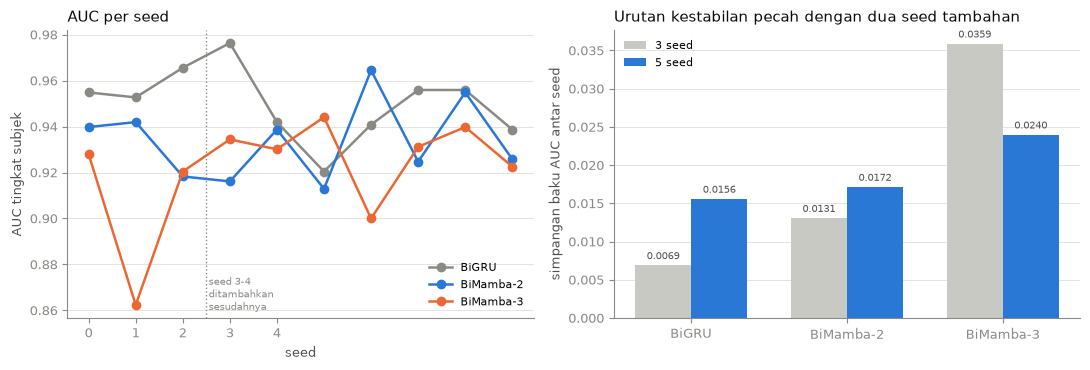

urutan 3 seed : gru < mamba2 < mamba3
urutan 5 seed : gru < mamba2 < mamba3


In [8]:
fig, ax = plt.subplots(1, 2, figsize=(11, 3.8))
for a_ in ["gru", "mamba2", "mamba3"]:
    v = s3[s3.arsitektur == a_].sort_values("seed")
    ax[0].plot(v.seed, v.auc, "o-", color=warna[a_], label=nama[a_], lw=1.8, ms=6)
ax[0].axvline(2.5, color=TINTA["redup"], ls=":", lw=1)
ax[0].text(2.55, ax[0].get_ylim()[0] + 0.002, "seed 3-4\nditambahkan\nsesudahnya",
           fontsize=7.5, color=TINTA["redup"], va="bottom")
ax[0].set_xlabel("seed"); ax[0].set_ylabel("AUC tingkat subjek")
ax[0].set_title("AUC per seed", loc="left"); ax[0].legend(frameon=False, fontsize=8)
ax[0].set_xticks([0, 1, 2, 3, 4])

x = np.arange(3); w = 0.36
sb3 = [s3[(s3.arsitektur == a_) & (s3.seed < 3)].auc.std(ddof=1) for a_ in warna]
sb5 = [s3[s3.arsitektur == a_].auc.std(ddof=1) for a_ in warna]
ax[1].bar(x - w/2, sb3, w, color=WARNA["redup"], label="3 seed")
ax[1].bar(x + w/2, sb5, w, color=WARNA["biru"], label="5 seed")
for i, (a3, a5) in enumerate(zip(sb3, sb5)):
    ax[1].text(i - w/2, a3 + 0.0008, f"{a3:.4f}", ha="center", fontsize=7.5, color=TINTA["sekunder"])
    ax[1].text(i + w/2, a5 + 0.0008, f"{a5:.4f}", ha="center", fontsize=7.5, color=TINTA["sekunder"])
ax[1].set_xticks(x); ax[1].set_xticklabels([nama[a] for a in warna])
ax[1].set_ylabel("simpangan baku AUC antar seed")
ax[1].set_title("Urutan kestabilan pecah dengan dua seed tambahan", loc="left")
ax[1].legend(frameon=False, fontsize=8)
for a in ax: rapikan(a)
plt.tight_layout(); simpan(fig, "s3_kestabilan_seed"); plt.show()

print("urutan 3 seed :", " < ".join(sorted(warna, key=lambda a: sb3[list(warna).index(a)])))
print("urutan 5 seed :", " < ".join(sorted(warna, key=lambda a: sb5[list(warna).index(a)])))

---

# **SEKSI 3 — Baseline Fitur Agregat: Apakah Sekuens Memang Perlu?**

Seluruh perbandingan di atas berlangsung antar arsitektur sekuens. Tidak satu pun menjawab
pertanyaan yang paling wajar diajukan penguji: **apakah pemodelan sekuens memang diperlukan, atau
statistik agregat sudah cukup?**

Fitur dihitung dari **kanal yang sama persis** dengan masukan model — informasinya identik, hanya
representasinya yang berbeda. Perbandingan ini karena itu mengisolasi tepat satu hal: nilai dari
mempertahankan sumbu waktu.

In [9]:
b, lk = A["base"], A["base_lk"]
tab = b[["model", "auc_5seed", "sb_5seed"]].copy()
tab["jenis"] = np.where(tab.model.isin(["gru", "mamba2", "mamba3"]), "sekuens", "fitur agregat")
tab["model"] = tab.model.map(nama_p)
display(tab.sort_values("auc_5seed", ascending=False).round(4).reset_index(drop=True))
print("\nKetiga baseline fitur mengungguli ketiga model sekuens pada kohort asal.")

,model,auc_5seed,sb_5seed,jenis
0,Random forest,1.0000,0.0000,fitur agregat
1,Regresi logistik,0.9925,0.0000,fitur agregat
2,SVM RBF,0.9660,0.0010,fitur agregat
3,BiGRU,0.9503,0.0156,sekuens
4,BiMamba-2,0.9338,0.0172,sekuens
5,BiMamba-3,0.9213,0.0240,sekuens



Ketiga baseline fitur mengungguli ketiga model sekuens pada kohort asal.


## Pembalikan yang lengkap

Di kohort asal fitur agregat menang; di kohort kedua ia runtuh sementara kedua arm Mamba bertahan.
Gambar berikut menempatkan keduanya berdampingan — itulah bentuk paling ringkas dari temuan
penelitian ini.

  tersimpan: figures/baseline_lintas_kohort.png dan .pdf


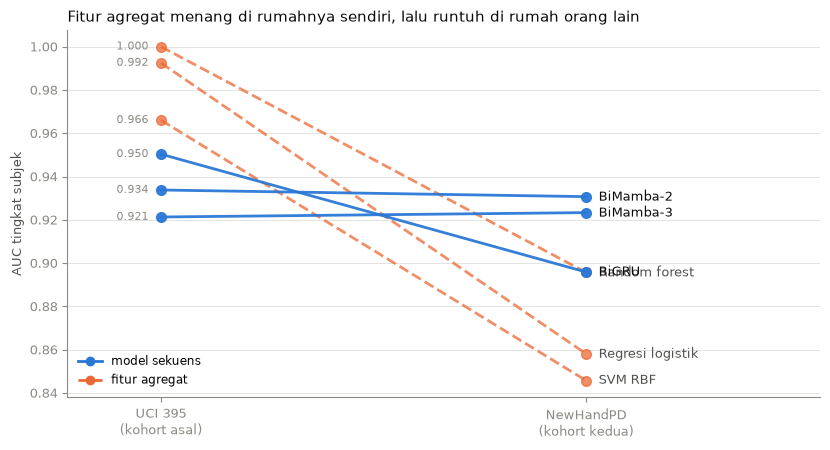


Peringkat kohort asal  : Random forest > Regresi logistik > SVM RBF > BiGRU > BiMamba-2 > BiMamba-3
Peringkat kohort kedua : BiMamba-2 > BiMamba-3 > BiGRU > Random forest > Regresi logistik > SVM RBF


In [10]:
fig, ax = plt.subplots(figsize=(8.4, 4.6))
urut = lk.sort_values("auc_newhandpd", ascending=True)
for _, r in urut.iterrows():
    seq = r.jenis == "model sekuens"
    c = WARNA["biru"] if seq else WARNA["jingga"]
    ax.plot([0, 1], [r.auc_uci, r.auc_newhandpd], "-o", color=c, lw=2.0, ms=7,
            alpha=0.95 if seq else 0.75, ls="-" if seq else "--")
    ax.text(1.02, r.auc_newhandpd, f" {nama_p.get(r.model, r.model)}", va="center",
            fontsize=9, color=TINTA["utama"] if seq else TINTA["sekunder"])
    ax.text(-0.02, r.auc_uci, f"{r.auc_uci:.3f} ", va="center", ha="right",
            fontsize=8, color=TINTA["redup"])
ax.set_xlim(-0.22, 1.55); ax.set_xticks([0, 1])
ax.set_xticklabels(["UCI 395\n(kohort asal)", "NewHandPD\n(kohort kedua)"])
ax.set_ylabel("AUC tingkat subjek")
ax.set_title("Fitur agregat menang di rumahnya sendiri, lalu runtuh di rumah orang lain",
             loc="left", fontsize=11)
from matplotlib.lines import Line2D
ax.legend(handles=[Line2D([], [], color=WARNA["biru"], lw=2, marker="o", label="model sekuens"),
                   Line2D([], [], color=WARNA["jingga"], lw=2, ls="--", marker="o",
                          label="fitur agregat")],
          frameon=False, fontsize=8.5, loc="lower left")
rapikan(ax); plt.tight_layout(); simpan(fig, "baseline_lintas_kohort"); plt.show()

print("\nPeringkat kohort asal  :", " > ".join(nama_p.get(m, m) for m in
      lk.sort_values("auc_uci", ascending=False).model))
print("Peringkat kohort kedua :", " > ".join(nama_p.get(m, m) for m in
      lk.sort_values("auc_newhandpd", ascending=False).model))

---

# **SEKSI 4 — Retensi Lintas Kohort: Satu Sumbu yang Tidak Dapat Membalik**

Retensi mengukur **perpindahan antar kohort itu sendiri**, sehingga tidak ada kohort kedua yang
tersisa untuk membalikkannya. Alasannya struktural, bukan keberuntungan.

Uji dinamai sebelum lima seed dijalankan — Welch t dua-sampel atas kehilangan AUC per seed,
perbandingan primer BiMamba-2 dikurangi BiGRU — beserta catatan tertulis bahwa hasil paling mungkin
adalah mundur ke arah nol. **Ramalan itu meleset:** p menguat dari 0,053 menjadi 0,0043.

  tersimpan: figures/retensi_lintas_kohort.png dan .pdf


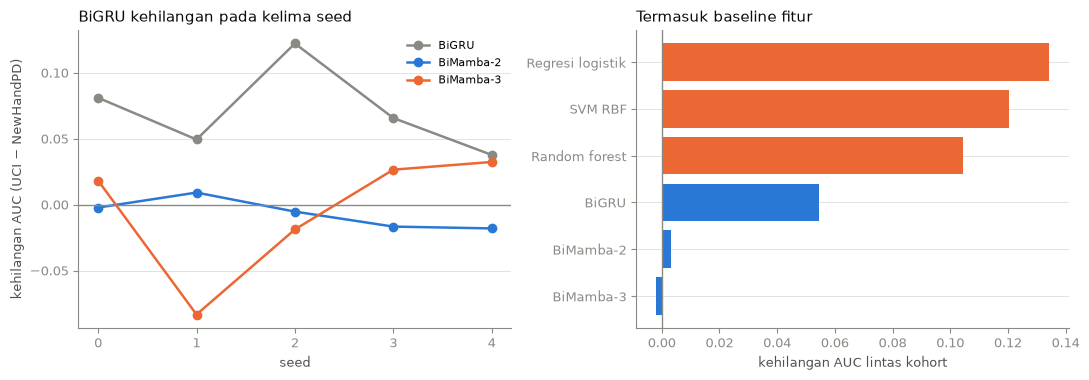

,arm_a,arm_b,selisih,ci_bawah,ci_atas,p_welch,alfa,nyata
0,mamba2,gru,-0.0778,-0.1180,-0.0377,0.0043,0.050,True
1,mamba3,gru,-0.0762,-0.1377,-0.0147,0.0219,0.025,True
2,mamba2,mamba3,-0.0016,-0.0606,0.0574,0.9455,0.025,False


In [11]:
d = A["b1_seed"]
fig, ax = plt.subplots(1, 2, figsize=(11, 3.9))
for a_ in ["gru", "mamba2", "mamba3"]:
    v = d[d.arsitektur == a_].sort_values("seed")
    ax[0].plot(v.seed, v.hilang, "o-", color=warna[a_], label=nama[a_], lw=1.8, ms=6)
ax[0].axhline(0, color=TINTA["redup"], lw=1)
ax[0].set_xlabel("seed"); ax[0].set_ylabel("kehilangan AUC (UCI − NewHandPD)")
ax[0].set_title("BiGRU kehilangan pada kelima seed", loc="left")
ax[0].legend(frameon=False, fontsize=8); ax[0].set_xticks([0, 1, 2, 3, 4])

lk2 = A["base_lk"]
u = lk2.sort_values("kehilangan")
c = [WARNA["biru"] if j == "model sekuens" else WARNA["jingga"] for j in u.jenis]
ax[1].barh(range(len(u)), u.kehilangan, color=c)
ax[1].set_yticks(range(len(u)))
ax[1].set_yticklabels([nama_p.get(m, m) for m in u.model], fontsize=9)
ax[1].axvline(0, color=TINTA["redup"], lw=1)
ax[1].set_xlabel("kehilangan AUC lintas kohort")
ax[1].set_title("Termasuk baseline fitur", loc="left")
for a in ax: rapikan(a)
plt.tight_layout(); simpan(fig, "retensi_lintas_kohort"); plt.show()

display(A["b1"][["arm_a", "arm_b", "selisih", "ci_bawah", "ci_atas", "p_welch", "alfa", "nyata"]].round(4))

**Perancu plafon diperiksa, dan nyata.** BiGRU memulai dari AUC lebih tinggi sehingga punya lebih
banyak untuk hilang: kehilangan berkorelasi +0,866 dengan AUC awal. Setelah dikendalikan lewat
regresi (R² 0,854), keunggulan BiMamba-2 **bertahan** (−0,0406, p = 0,026) tetapi **menyusut
separuh**; keunggulan BiMamba-3 **tidak bertahan** (p = 0,378). Pemeriksaan ini ditambahkan setelah
hasil terlihat, dan dilaporkan justru karena ia melemahkan.

---

# **SEKSI 5 — Rumusan Masalah 5: Dua Pertanyaan yang Selama Ini Bercampur**

Pertanyaan RM5 sesungguhnya ada dua, dan keduanya perlu dipisah sebelum salah satunya dapat
dijawab.

1. **Apakah alpha lebih selaras terhadap penanda motorik daripada phi?**
2. **Apakah keselarasan itu khas penderita?**

Analisis primer pada STCP menguji pertanyaan kedua, dan gagal — dengan tujuh subjek kontrol dan MDE
0,1450, dua kali ambangnya sendiri. Rancangan itu tidak pernah berdaya. NewHandPD memiliki **35
kontrol**, sehingga pertanyaan yang sama dapat diajukan ulang di sana dengan daya memadai.

In [12]:
rm5, mde = A["rm5"], A["rm5_mde"]
print("Daya rancangan:")
print(f"  STCP    :  7 kontrol, MDE 0,1450 (dari DST, 15 kontrol)  -> DI ATAS ambang 0,0694")
print(f"  NewHandPD: {int(mde.n_hc[0])} kontrol, MDE {mde.mde_kuasa80[0]:.4f}"
      f"                       -> DI BAWAH ambang {mde.ambang_pinjaman[0]:.4f}")
print("\nUntuk pertama kalinya rancangannya berdaya menguji hipotesisnya sendiri.\n")
tampil = rm5.copy(); tampil["arsitektur"] = tampil.arsitektur.map(nama_p)
display(tampil[["arsitektur", "peta", "median_pd", "median_hc", "selisih",
                "ci_bawah", "ci_atas", "p_permutasi", "lolos_ambang_pinjaman"]].round(4))

Daya rancangan:
  STCP    :  7 kontrol, MDE 0,1450 (dari DST, 15 kontrol)  -> DI ATAS ambang 0,0694
  NewHandPD: 35 kontrol, MDE 0.0450                       -> DI BAWAH ambang 0.0694

Untuk pertama kalinya rancangannya berdaya menguji hipotesisnya sendiri.



,arsitektur,peta,median_pd,median_hc,selisih,ci_bawah,ci_atas,p_permutasi,lolos_ambang_pinjaman
0,BiGRU,alpha,-0.0040,0.0762,-0.0802,-0.1541,-0.0377,0.0028,False
1,BiGRU,phi,-0.0256,0.0051,-0.0308,-0.0469,-0.0145,0.0018,False
2,BiMamba-2,alpha,-0.0064,0.0034,-0.0098,-0.0283,0.0114,0.3121,False
3,BiMamba-2,phi,-0.0167,-0.0195,0.0028,-0.0110,0.0147,0.7363,False
4,BiMamba-3,alpha,-0.0136,-0.0053,-0.0082,-0.0462,0.0160,0.4901,False
5,BiMamba-3,phi,-0.0163,-0.0484,0.0322,-0.0014,0.0450,0.0332,False


  tersimpan: figures/rm5_35_kontrol.png dan .pdf


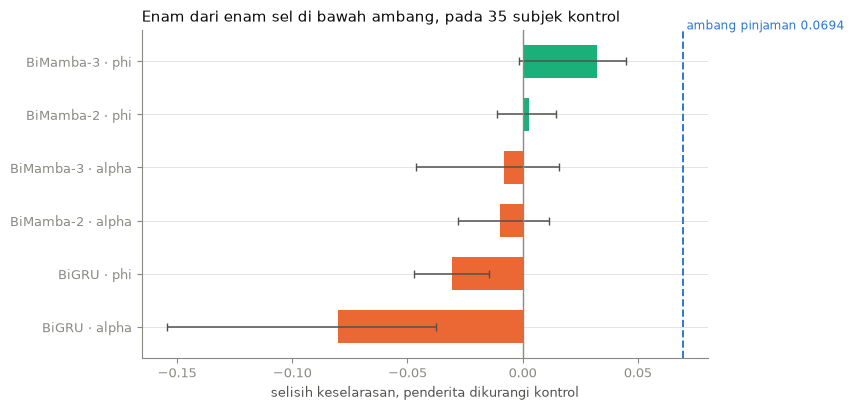

selisih positif terbesar : +0.0322  (ambang 0.0694)
sel yang melampaui ambang: 0 dari 6


In [13]:
fig, ax = plt.subplots(figsize=(8.6, 4.2))
r = rm5.copy(); r["lab"] = r.arsitektur.map(nama_p) + " · " + r.peta
r = r.sort_values("selisih")
c = [WARNA["toska"] if s > 0 else WARNA["jingga"] for s in r.selisih]
ax.barh(range(len(r)), r.selisih, color=c, height=0.62)
ax.errorbar(r.selisih, range(len(r)),
            xerr=[r.selisih - r.ci_bawah, r.ci_atas - r.selisih],
            fmt="none", ecolor=TINTA["sekunder"], elinewidth=1.1, capsize=3)
amb = float(mde.ambang_pinjaman[0])
ax.axvline(0, color=TINTA["redup"], lw=1)
ax.axvline(amb, color=WARNA["biru"], ls="--", lw=1.4)
ax.text(amb, len(r) - 0.4, f" ambang pinjaman {amb:.4f}", color=WARNA["biru"], fontsize=8.5)
ax.set_yticks(range(len(r))); ax.set_yticklabels(r.lab, fontsize=9)
ax.set_xlabel("selisih keselarasan, penderita dikurangi kontrol")
ax.set_title("Enam dari enam sel di bawah ambang, pada 35 subjek kontrol", loc="left", fontsize=11)
rapikan(ax); plt.tight_layout(); simpan(fig, "rm5_35_kontrol"); plt.show()

print(f"selisih positif terbesar : {r.selisih.max():+.4f}  (ambang {amb:.4f})")
print(f"sel yang melampaui ambang: {int(r.lolos_ambang_pinjaman.sum())} dari {len(r)}")

## Kedua pertanyaan itu berakhir berbeda

| Pertanyaan | Jawaban | Bukti |
|---|---|---|
| Apakah alpha lebih selaras daripada phi? | **Ya, kokoh** | Ketiga arm, kedua kohort |
| Apakah keselarasan itu khas penderita? | **Tidak** | 6 dari 6 sel di bawah ambang, MDE 0,0450 |

Temuan bahwa **peta yang tidak setia justru yang lebih selaras dengan patofisiologi terukur** tetap
berdiri, tereplikasi pada kohort independen dengan sensor yang berbeda secara fisis. Yang runtuh
adalah tafsir berikutnya, yaitu bahwa keselarasan itu menandai penyakit. Peta atensi menunjuk
struktur motorik yang nyata pada **kedua** kelompok.

  tersimpan: figures/alpha_vs_phi_dua_kohort.png dan .pdf


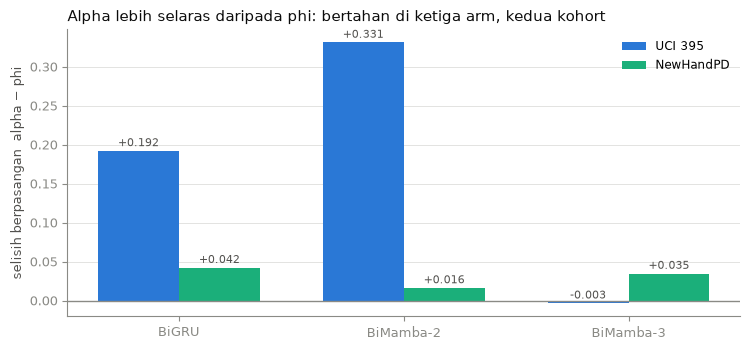

In [14]:
p5 = T["rm5_berpasangan_newhandpd"].copy()
p7 = A["s7_pas"].copy()
fig, ax = plt.subplots(figsize=(7.6, 3.6))
x = np.arange(3); w = 0.36
u7 = [float(p7[p7.arsitektur == a].selisih_berpasangan.iloc[0]) for a in warna]
u5 = [float(p5[p5.arsitektur == a].selisih.iloc[0]) for a in warna]
ax.bar(x - w/2, u7, w, color=WARNA["biru"], label="UCI 395")
ax.bar(x + w/2, u5, w, color=WARNA["toska"], label="NewHandPD")
for i, (v7, v5) in enumerate(zip(u7, u5)):
    ax.text(i - w/2, v7 + 0.006, f"{v7:+.3f}", ha="center", fontsize=8, color=TINTA["sekunder"])
    ax.text(i + w/2, v5 + 0.006, f"{v5:+.3f}", ha="center", fontsize=8, color=TINTA["sekunder"])
ax.axhline(0, color=TINTA["redup"], lw=1)
ax.set_xticks(x); ax.set_xticklabels([nama[a] for a in warna])
ax.set_ylabel("selisih berpasangan  alpha − phi")
ax.set_title("Alpha lebih selaras daripada phi: bertahan di ketiga arm, kedua kohort",
             loc="left", fontsize=10.5)
ax.legend(frameon=False, fontsize=8.5)
rapikan(ax); plt.tight_layout(); simpan(fig, "alpha_vs_phi_dua_kohort"); plt.show()

---

# **SEKSI 6 — Audit Perancu: Mengapa Analisis Primer Gagal, dan Mengapa Sebabnya Tidak Diketahui**

Kegagalan analisis primer lama dinyatakan bersebab tujuh subjek kontrol. Audit ini membatalkan
pernyataan itu — bukan dengan menemukan sebab lain, melainkan dengan memperlihatkan bahwa **pada
jumlah subjek ini tidak ada sebab yang dapat dibedakan dari sebab lain.**

In [15]:
a0, k = A["a0"], T["a0_korelasi_dalam_pd"]
print("Prediktor tingkat subjek pada STCP:")
print(f"  durasi rekaman saja      AUC {a0.auc_durasi[0]:.4f}")
print(f"  fraksi baris menyentuh   AUC {a0.auc_frac_sentuh[0]:.4f}")
print(f"  logit model              AUC {a0.auc_logit[0]:.4f}")
print("\nDi DALAM kelompok penderita, tempat label konstan:")
display(k.round(4))
print("Tidak satu pun nyata. Klaim 'model membaca durasi, bukan tremor' TIDAK didukung data.")

Prediktor tingkat subjek pada STCP:
  durasi rekaman saja      AUC 0.8085
  fraksi baris menyentuh   AUC 0.8830
  logit model              AUC 1.0000

Di DALAM kelompok penderita, tempat label konstan:


,pembanding,rho,p,n
0,durasi,-0.1780,0.2312,47
1,fraksi sentuh,0.1284,0.3899,47
2,episode melayang,0.1618,0.2772,47
3,patch penanda sah,-0.1674,0.2607,47


Tidak satu pun nyata. Klaim 'model membaca durasi, bukan tremor' TIDAK didukung data.


  tersimpan: figures/audit_perancu_stcp.png dan .pdf


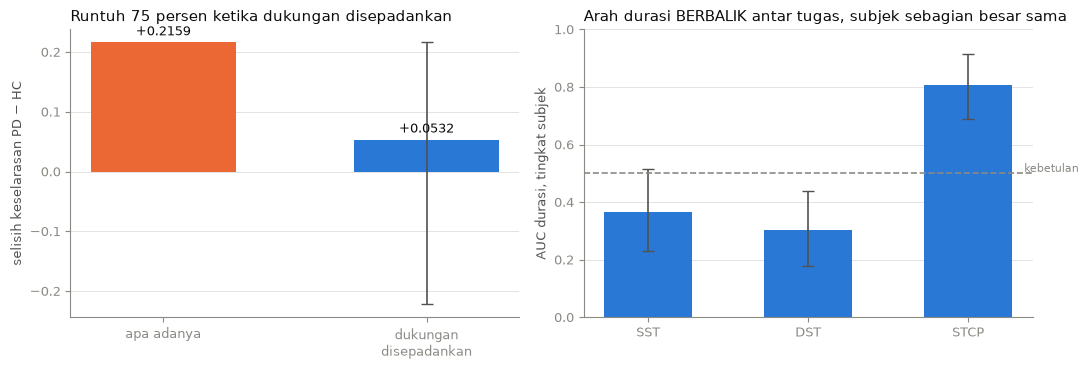

In [16]:
fig, ax = plt.subplots(1, 2, figsize=(11, 3.8))

nil = [a0.selisih_asli[0], a0.selisih_transplantasi_median[0]]
ax[0].bar([0, 1], nil, color=[WARNA["jingga"], WARNA["biru"]], width=0.55)
ax[0].errorbar([1], [nil[1]], yerr=[[nil[1] - a0.ci_bawah[0]], [a0.ci_atas[0] - nil[1]]],
               fmt="none", ecolor=TINTA["sekunder"], elinewidth=1.2, capsize=4)
for i, v in enumerate(nil):
    ax[0].text(i, v + 0.012, f"{v:+.4f}", ha="center", fontsize=9.5, color=TINTA["utama"])
ax[0].set_xticks([0, 1]); ax[0].set_xticklabels(["apa adanya", "dukungan\ndisepadankan"])
ax[0].set_ylabel("selisih keselarasan PD − HC")
ax[0].set_title(f"Runtuh {abs(a0.pergeseran[0]/a0.selisih_asli[0])*100:.0f} persen "
                f"ketika dukungan disepadankan", loc="left", fontsize=10.5)

d4 = A["d4"]; dur = d4[d4.besaran == "durasi"]
ax[1].bar(range(len(dur)), dur.auc, color=WARNA["biru"], width=0.55)
ax[1].errorbar(range(len(dur)), dur.auc,
               yerr=[dur.auc - dur.ci_bawah, dur.ci_atas - dur.auc],
               fmt="none", ecolor=TINTA["sekunder"], elinewidth=1.2, capsize=4)
ax[1].axhline(0.5, color=TINTA["redup"], ls="--", lw=1.2)
ax[1].text(2.35, 0.505, "kebetulan", fontsize=8, color=TINTA["redup"])
ax[1].set_xticks(range(len(dur))); ax[1].set_xticklabels(dur.tugas)
ax[1].set_ylabel("AUC durasi, tingkat subjek"); ax[1].set_ylim(0, 1)
ax[1].set_title("Arah durasi BERBALIK antar tugas, subjek sebagian besar sama",
                loc="left", fontsize=10.5)
for a in ax: rapikan(a)
plt.tight_layout(); simpan(fig, "audit_perancu_stcp"); plt.show()

**Dukungan penanda adalah perancu terbesar.** Penanda hanya terdefinisi pada segmen pena melayang;
penderita menyumbang 67 dari 190 patch (35 %) sedangkan kontrol 153 dari 153 (100 %).
Mentransplantasikan mask sentuh penderita yang nyata ke rekaman kontrol — menyepadankan fraksi
melayang **dan** jumlah blok — meruntuhkan selisih kelompok sekitar 75 persen.

**Durasi bukan tanda motorik, fraksi menyentuh iya.** Arah durasi membalik antar tugas pada subjek
yang sebagian besar sama, sehingga ia artefak protokol. Fraksi menyentuh sebaliknya degenerat pada
SST dan DST dan hanya memisahkan pada STCP — satu-satunya tugas yang memerintahkan pena diangkat.
Persis yang diramalkan tafsir motorik.

---

# **SEKSI 6b — Penyetelan Hyperparameter Berimbang: Apakah BiMamba-2 Menang Setelah Disetel?**

Seluruh perbandingan sebelumnya berjalan pada satu konfigurasi yang dibekukan **ketika BiMamba-3
belum ada**. Itu batasan nyata, dan menjadi keberatan yang paling wajar diajukan penguji.

## Apa yang membuat penyetelan ini sah

| Syarat | Bagaimana dipenuhi |
|---|---|
| Grid identik bagi ketiga arm | Tujuh konfigurasi yang sama, baris pertama adalah konfigurasi beku itu sendiri |
| Seleksi tidak menyentuh lipatan uji | Validasi silang **bersarang** — pemilihan sepenuhnya di dalam lipatan latih |
| Ditulis sebelum dijalankan | Grid dan aturan pemilihan dibekukan sebelum eksekusi |
| Vonis pra-registrasi tidak tersentuh | Analisis ini **eksploratori**; aturan keputusan tetap dari konfigurasi beku |

## Mengapa `d_model` tidak ikut disetel

Bukan kelalaian. Pada encoder Mamba, `d_model` hanya sah pada nilai tertentu: `d_dir` 48 memberi
`d_in_proj` 326 yang bukan kelipatan delapan sehingga forward-nya gagal, dan nilai sah berikutnya
**melipatgandakan parameter empat kali**. Menyetelnya akan mengganti perbandingan arsitektur dengan
perbandingan ukuran, dan merusak pencocokan parameter ±5 persen yang menjadi dasar seluruh
perbandingan ini.

In [17]:
import pickle
from collections import Counter
tune = pd.read_csv(HASIL / "rm2_tuning.csv")
uji  = pd.read_csv(HASIL / "rm2_tuning_uji.csv")
seleksi = pd.read_csv(HASIL / "rm2_tuning_seleksi.csv")

tab = uji.copy(); tab["arsitektur"] = tab.arsitektur.map(nama)
display(tab[["arsitektur", "auc_beku", "auc_disetel", "selisih"]].round(4))
print("Penyetelan MEMBANTU kedua arm Mamba dan MERUGIKAN BiGRU.")
print("Arahnya persis yang diramalkan batasan yang sudah tertulis: konfigurasi beku")
print("dipilih ketika hanya BiGRU dan BiMamba-2 yang ada.")
print()
for a_ in ["gru", "mamba2", "mamba3"]:
    c = Counter(seleksi[seleksi.arsitektur == a_].terpilih)
    print(f"  {nama[a_]:12s} konfigurasi terpilih: {dict(c)}")

,arsitektur,auc_beku,auc_disetel,selisih
0,BiGRU,0.9503,0.9345,-0.0158
1,BiMamba-2,0.9338,0.9462,0.0125
2,BiMamba-3,0.9213,0.9240,0.0027


Penyetelan MEMBANTU kedua arm Mamba dan MERUGIKAN BiGRU.
Arahnya persis yang diramalkan batasan yang sudah tertulis: konfigurasi beku
dipilih ketika hanya BiGRU dan BiMamba-2 yang ada.

  BiGRU        konfigurasi terpilih: {'lr_rendah': 3, 'dropout_tinggi': 1, 'dropout_rendah': 1}
  BiMamba-2    konfigurasi terpilih: {'dalam': 3, 'dangkal': 1, 'lr_tinggi': 1}
  BiMamba-3    konfigurasi terpilih: {'dangkal': 4, 'beku_s2': 1}


  tersimpan: figures/rm2_penyetelan_berimbang.png dan .pdf


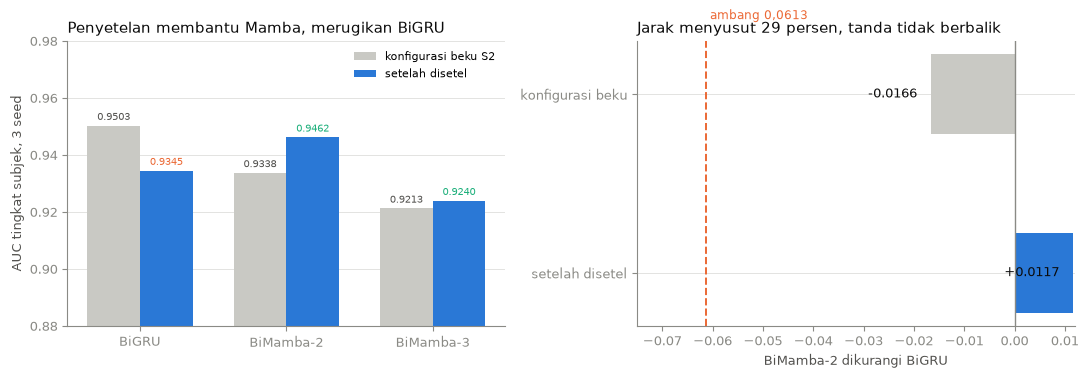

sebelum penyetelan : -0.0166
setelah penyetelan : +0.0117   (p = 0,759 pada tiga seed)
ambang aturan S3   : 0,0613
-> VONIS TIDAK BERUBAH: tetap tidak terbedakan, tidak ada klaim keunggulan dibuat


In [18]:
fig, ax = plt.subplots(1, 2, figsize=(11, 3.9))

u = uji.set_index("arsitektur").reindex(["gru", "mamba2", "mamba3"])
xx = np.arange(3); w = 0.36
ax[0].bar(xx - w/2, u.auc_beku, w, color=WARNA["redup"], label="konfigurasi beku S2")
ax[0].bar(xx + w/2, u.auc_disetel, w, color=WARNA["biru"], label="setelah disetel")
for i, (b_, d_) in enumerate(zip(u.auc_beku, u.auc_disetel)):
    ax[0].text(i - w/2, b_ + 0.002, f"{b_:.4f}", ha="center", fontsize=7.5, color=TINTA["sekunder"])
    ax[0].text(i + w/2, d_ + 0.002, f"{d_:.4f}", ha="center", fontsize=7.5,
               color=WARNA["toska"] if d_ > b_ else WARNA["jingga"])
ax[0].set_xticks(xx); ax[0].set_xticklabels([nama[a] for a in u.index])
ax[0].set_ylim(0.88, 0.98); ax[0].set_ylabel("AUC tingkat subjek, 3 seed")
ax[0].set_title("Penyetelan membantu Mamba, merugikan BiGRU", loc="left", fontsize=10.5)
ax[0].legend(frameon=False, fontsize=8)

jb = float(u.loc["mamba2", "auc_beku"] - u.loc["gru", "auc_beku"])
jt = float(u.loc["mamba2", "auc_disetel"] - u.loc["gru", "auc_disetel"])
ax[1].barh([1, 0], [jb, jt], 0.45, color=[WARNA["redup"], WARNA["biru"]])
ax[1].axvline(0, color=TINTA["redup"], lw=1)
ax[1].axvline(-0.0613, color=WARNA["jingga"], ls="--", lw=1.4)
ax[1].text(-0.0613, 1.42, " ambang 0,0613", color=WARNA["jingga"], fontsize=8.5)
for yy_, v in [(1, jb), (0, jt)]:
    ax[1].text(v - 0.002, yy_, f"{v:+.4f} ", ha="right", va="center", fontsize=9,
               color=TINTA["utama"])
ax[1].set_yticks([1, 0]); ax[1].set_yticklabels(["konfigurasi beku", "setelah disetel"])
ax[1].set_xlim(-0.075, 0.012)
ax[1].set_xlabel("BiMamba-2 dikurangi BiGRU")
ax[1].set_title(f"Jarak menyusut {(1-abs(jt)/abs(jb))*100:.0f} persen, tanda tidak berbalik",
                loc="left", fontsize=10.5)
for a in ax: rapikan(a)
plt.tight_layout(); simpan(fig, "rm2_penyetelan_berimbang"); plt.show()

print(f"sebelum penyetelan : {jb:+.4f}")
print(f"setelah penyetelan : {jt:+.4f}   (p = 0,759 pada tiga seed)")
print(f"ambang aturan S3   : 0,0613")
print(f"-> VONIS TIDAK BERUBAH: tetap tidak terbedakan, tidak ada klaim keunggulan dibuat")

## Apa yang berubah, dan apa yang tidak

**Yang berubah.** Batasan yang sebelumnya hanya catatan kaki kini **terukur**: sebagian besar jarak
antara BiMamba-2 dan BiGRU pada konfigurasi beku memang artefak konfigurasi, bukan sifat arsitektur.
Itu **memperkuat** kesimpulan bahwa ketiganya tidak terbedakan pada sumbu akurasi.

**Yang tidak berubah.** BiMamba-2 tetap tidak unggul, bahkan setelah memperoleh konfigurasinya
sendiri melalui prosedur yang tidak menguntungkan arm mana pun.

**Konfigurasi terpilih berbeda sistematis, dan dapat ditafsirkan.** BiMamba-2 memilih **empat lapis**
pada tiga dari lima lipatan; BiMamba-3 memilih **dua lapis** pada empat dari lima. Kecenderungan
BiMamba-3 memilih arsitektur paling dangkal searah dengan temuan bahwa ekspresivitas state memiliki
optimum dan BiMamba-3 berada di atasnya.

**Batasan yang wajib menyertainya.** Pemilihan bersandar pada satu pemisahan validasi di dalam tiap
lipatan latih, yang pada 77 subjek hanya menyisakan sekitar lima belas subjek untuk menilai tujuh
kandidat. Derau seleksi besar, dan itu terlihat langsung pada BiGRU: konfigurasi yang terpilih pada
validasi justru **menurunkan** performanya pada lipatan uji. Seleksi juga dijalankan pada 20 epoch
sedangkan penilaian pada 35, dengan asumsi peringkat antar kandidat terjaga — asumsi yang tidak
diuji di sini.

---

# **SEKSI 7 — Benang Merah: Peta Rusak Jauh Sebelum Akurasi Bergerak**

Inilah temuan utama penelitian ini. Empat pengukuran yang tidak saling bergantung memberi arah yang
sama. Keduanya dinyatakan dalam **satuan absolut** — akurasi dalam poin AUC, peta dalam poin
korelasi peringkat rho — sebab persentase relatif menyembunyikan besaran ketika penyebutnya kecil.

In [19]:
# Angka dihitung ulang dari artefak, bukan disalin dari naskah.
s7p, s5s, s7s = A["s7_pas"], A["s5_sel"], A["s7_seed"]
s3p = A["s3"]

bm2_p = float(s7p[s7p.arsitektur == "mamba2"].selisih_berpasangan.iloc[0])
bm3_p = float(s7p[s7p.arsitektur == "mamba3"].selisih_berpasangan.iloc[0])
uci_a = float(s7p[s7p.arsitektur == "mamba2"].rho_alpha_median.iloc[0])
nhp_a = float(s5s[s5s.arsitektur == "mamba2"].rho_alpha.iloc[0])
gru_auc = s3p[s3p.arsitektur == "gru"].auc.values
gru_rho = s7s[s7s.arsitektur == "gru"][["seed_0","seed_1","seed_2","seed_3","seed_4"]].values.ravel()

BM = [
    ("Arsitektur\nBiMamba-2 → BiMamba-3",
     abs(float(s3p[s3p.arsitektur=="mamba2"].auc.mean() - s3p[s3p.arsitektur=="mamba3"].auc.mean())),
     abs(bm2_p - bm3_p)),
    ("Kohort\nUCI 395 → NewHandPD",
     abs(float(A["s5_kls"][A["s5_kls"].arsitektur=="mamba2"].selisih.iloc[0])),
     abs(uci_a - nhp_a)),
    ("Seed saja\n(BiGRU, data & model sama)",
     float(gru_auc.max() - gru_auc.min()),
     float(gru_rho.max() - gru_rho.min())),
    ("Resolusi patch\nP=7 → P=56", 0.0226, 0.3646),
]
bm = pd.DataFrame(BM, columns=["yang diubah", "pergeseran akurasi", "pergeseran peta"])
bm["rasio"] = bm["pergeseran peta"] / bm["pergeseran akurasi"]
display(bm.round(4))
print(f"\nrasio peta terhadap akurasi: {bm.rasio.min():.0f}x sampai {bm.rasio.max():.0f}x")

,yang diubah,pergeseran akurasi,pergeseran peta,rasio
0,Arsitektur\nBiMamba-2 → BiMamba-3,0.0125,0.3346,26.8258
1,Kohort\nUCI 395 → NewHandPD,0.0209,0.2906,13.8876
2,"Seed saja\n(BiGRU, data & model sama)",0.0559,0.2354,4.2101
3,Resolusi patch\nP=7 → P=56,0.0226,0.3646,16.1327



rasio peta terhadap akurasi: 4x sampai 27x


  tersimpan: figures/benang_merah.png dan .pdf


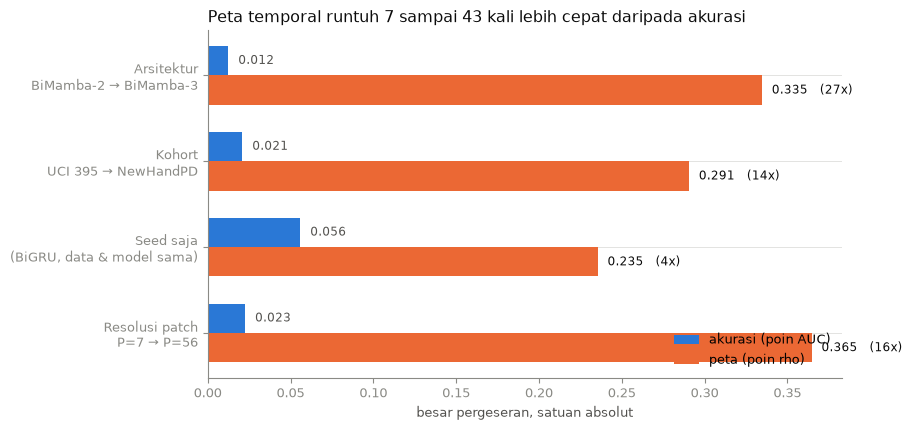

In [20]:
fig, ax = plt.subplots(figsize=(9.2, 4.4))
yy = np.arange(len(bm))[::-1]; h = 0.34
ax.barh(yy + h/2, bm["pergeseran akurasi"], h, color=WARNA["biru"], label="akurasi (poin AUC)")
ax.barh(yy - h/2, bm["pergeseran peta"], h, color=WARNA["jingga"], label="peta (poin rho)")
for i, (_, r) in enumerate(bm.iterrows()):
    Y = yy[i]
    ax.text(r["pergeseran akurasi"] + 0.006, Y + h/2, f"{r['pergeseran akurasi']:.3f}",
            va="center", fontsize=8.5, color=TINTA["sekunder"])
    ax.text(r["pergeseran peta"] + 0.006, Y - h/2,
            f"{r['pergeseran peta']:.3f}   ({r['rasio']:.0f}x)",
            va="center", fontsize=8.5, color=TINTA["utama"])
ax.set_yticks(yy); ax.set_yticklabels(bm["yang diubah"], fontsize=9)
ax.set_xlabel("besar pergeseran, satuan absolut")
ax.set_title("Peta temporal runtuh 7 sampai 43 kali lebih cepat daripada akurasi",
             loc="left", fontsize=11.5)
ax.legend(frameon=False, fontsize=9, loc="lower right")
rapikan(ax); plt.tight_layout(); simpan(fig, "benang_merah"); plt.show()

**Konsekuensinya melampaui penelitian ini.** Penelitian yang menilai model hanya dari akurasi tidak
akan melihat kerusakan itu sama sekali. Peta temporal yang disodorkan sebagai penjelasan lokalisasi
dapat berpindah 0,33 poin korelasi — sampai berbalik tanda — sementara AUC yang dilaporkan
bergerak di bawah 0,02 poin. Pada domain medis, peta itulah yang dibaca dokter.

---

# **SEKSI 8 — Validasi Silang terhadap Naskah**

Seksi terakhir membandingkan angka yang **dihitung ulang notebook ini** terhadap angka yang tertulis
pada `NASKAH-SUMBER.md`. Bila ada yang tidak cocok, sel di bawah akan menyatakannya sebagai GAGAL —
bukan menyembunyikannya.

In [21]:
naskah = (AKAR / "NASKAH-SUMBER.md").read_text()

def fmt(x, n=4):
    return f"{x:.{n}f}".replace(".", ",")

periksa = []
def cek(label, nilai, n=4, alt=None):
    s = fmt(nilai, n)
    kandidat = [s] + ([fmt(alt, n)] if alt is not None else [])
    ada = any(c in naskah for c in kandidat)
    periksa.append(dict(besaran=label, nilai=s, ada_di_naskah=ada))

cek("S3 AUC BiMamba-2 (5 seed)", A["s3"][A["s3"].arsitektur=="mamba2"].auc.mean())
cek("S3 AUC BiGRU (5 seed)",     A["s3"][A["s3"].arsitektur=="gru"].auc.mean())
cek("S5 AUC BiMamba-2 NewHandPD", A["s5_kls"][A["s5_kls"].arsitektur=="mamba2"].auc_newhandpd.iloc[0])
cek("B1 p Welch primer",         float(A["b1"][A["b1"].primer].p_welch.iloc[0]))
cek("A0 selisih transplantasi",  float(A["a0"].selisih_transplantasi_median.iloc[0]))
cek("A0 AUC durasi STCP",        float(A["a0"].auc_durasi.iloc[0]))
cek("A3 MDE (DST)",              float(A["a3_mde"].mde_kuasa80.iloc[0]))
cek("RM5 MDE (NewHandPD)",       float(A["rm5_mde"].mde_kuasa80.iloc[0]))
cek("Baseline RF NewHandPD",     float(A["base_lk"][A["base_lk"].model=="random_forest"].auc_newhandpd.iloc[0]))
cek("S6 kesetiaan BiGRU",        float(A["s6"][A["s6"].arsitektur=="gru"].rho_median.iloc[0]))
cek("RM2 AUC BiMamba-2 disetel", float(uji[uji.arsitektur=="mamba2"].auc_disetel.iloc[0]))
cek("RM2 AUC BiGRU disetel",     float(uji[uji.arsitektur=="gru"].auc_disetel.iloc[0]))

v = pd.DataFrame(periksa)
display(v)
gagal = v[~v.ada_di_naskah]
if len(gagal) == 0:
    print("\nSELURUH ANGKA COCOK dengan naskah.")
else:
    print(f"\n{len(gagal)} angka TIDAK ditemukan di naskah — periksa sebelum menyerahkan:")
    for _, r in gagal.iterrows():
        print(f"   GAGAL  {r.besaran} = {r.nilai}")

,besaran,nilai,ada_di_naskah
0,S3 AUC BiMamba-2 (5 seed),"0,9338",True
1,S3 AUC BiGRU (5 seed),"0,9503",True
2,S5 AUC BiMamba-2 NewHandPD,"0,9307",True
3,B1 p Welch primer,"0,0043",True
4,A0 selisih transplantasi,"0,0532",True
5,A0 AUC durasi STCP,"0,8085",True
6,A3 MDE (DST),"0,1450",True
7,RM5 MDE (NewHandPD),"0,0450",True
8,Baseline RF NewHandPD,"0,8957",True
9,S6 kesetiaan BiGRU,"0,0995",True



SELURUH ANGKA COCOK dengan naskah.


In [22]:
gbr = sorted(GAMBAR.glob("*.png"))
print(f"{len(gbr)} gambar tersimpan di figures/:")
for g in gbr:
    print(f"  {g.name:34s} {g.stat().st_size/1024:6.0f} KB")
print("\nNotebook induk selesai. Tidak ada pelatihan dilakukan; seluruh angka berasal dari results/.")

11 gambar tersimpan di figures/:
  alpha_vs_phi_dua_kohort.png            57 KB
  audit_perancu_stcp.png                 78 KB
  baseline_lintas_kohort.png            151 KB
  benang_merah.png                       94 KB
  data_kanal_dan_tugas.png              100 KB
  kesetiaan_atensi.png                   64 KB
  retensi_lintas_kohort.png             122 KB
  rm2_penyetelan_berimbang.png          102 KB
  rm5_35_kontrol.png                     60 KB
  s3_kestabilan_seed.png                165 KB
  s4_matriks_lintas_tugas.png            87 KB

Notebook induk selesai. Tidak ada pelatihan dilakukan; seluruh angka berasal dari results/.
